# 4장 — 단순 네트워크에서 다중 소스 통합으로

| | |
| --- | --- |
| **책** | Alessandro Negro 외, *Knowledge Graphs and LLMs in Action* (Manning, 2025) **4장** |
| **해설 원본** | [04_..._ko_explained.md 열기](../../04_from_simple_networks_to_multisource_integration_ko_explained.md) |
| **이 폴더** | [tasks.py](./tasks.py) · [listings/](./listings) · [importer/](./importer) · [analysis/](./analysis) |
| **원서 저장소** | [alenegro81/.../chapters/ch04 열기](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch04) |
| **리스팅 번호** | **오프셋 0** — 책 번호 = 파일 번호 (예: 책 4.9 = 파일 `4.9 Run WCC on the PPI Network`). 3장은 −3 이었다. 챕터마다 다르므로 복사하면 안 된다 |

---

3장은 온톨로지 **하나** 로 지식 그래프를 지었다. 4장은 **이미 그래프로 다루기 좋은 형태로 제공되는 여러 구조화 소스** 를 합친다. 그래서 초점이 "어떻게 모델링하고, 어떻게 통합하고, 어떻게 분석하나"로 옮겨간다.

| 절 | 내용 | 데이터베이스 | 실습 |
| --- | --- | --- | --- |
| 4.1 | 생명의학 KG 가 푸는 문제 유형 | — | — |
| 4.2 | 다중 오믹스: PPI + 질병 네트워크 | `ppi` | 실습 4-A |
| 4.3 | 제약: 약물 재활용과 DWPC | `hetionet` | 실습 4-B, 4-C |
| 4.4 | 임상: 정밀 의료와 CKG | `ckg` (선택) | — |
| — | 요약·용어·실측 대비 | — | — |

> **한 문장 요약** — 여러 생명의학 소스를 하나의 그래프로 합친 뒤, **커뮤니티 탐지** 로 전체 구조를 보고, **질병 경로 지표**(가장 큰 컴포넌트·밀도·전도도)로 부분 구조를 재고, **DWPC 메타경로** 로 흔한 노드에 속지 않는 순위를 뽑아 약물 재활용 후보를 찾는다.

이 장에서 **LLM은 보조 역할만** 한다. 소스가 CSV·관계형 DB·API 처럼 이미 구조화돼 있으므로 전통적 데이터 통합 기법이 주력이고, LLM 은 4.3.2 에서 순위표를 사람이 읽을 서사로 바꾸는 데만 쓰인다. 데이터가 이미 정돈돼 있으면 지어낼 위험이 있는 달변가에게 통합을 맡길 이유가 없다.

## 4.1 생명의학 지식 그래프가 푸는 문제

해설판은 다섯 가지 질문으로 장을 연다. 모두 "흩어진 사실을 노드와 관계로 엮어두면 겉으로 드러나지 않던 연결을 그래프 위에서 추론할 수 있다"는 하나의 전제를 공유한다.

- 질병과 단백질 사이 이미 알려진 관계에서 출발해 **새로운 연결** 을 발견할 수 있을까

- 값비싼 시험관 실험 없이 마이크로 RNA 와 질병의 의미 있는 관계를 찾아낼 수 있을까

- 셀리악병 같은 특정 질병에 관여하는 **핵심 과정** 은 무엇일까

- 수년의 연구 없이 기존 약물의 **새로운 용도(repurposing)** 를 찾아낼 수 있을까

- 환자 개개인의 정보를 활용하는 **정밀 의료** 를 어떻게 뒷받침할까

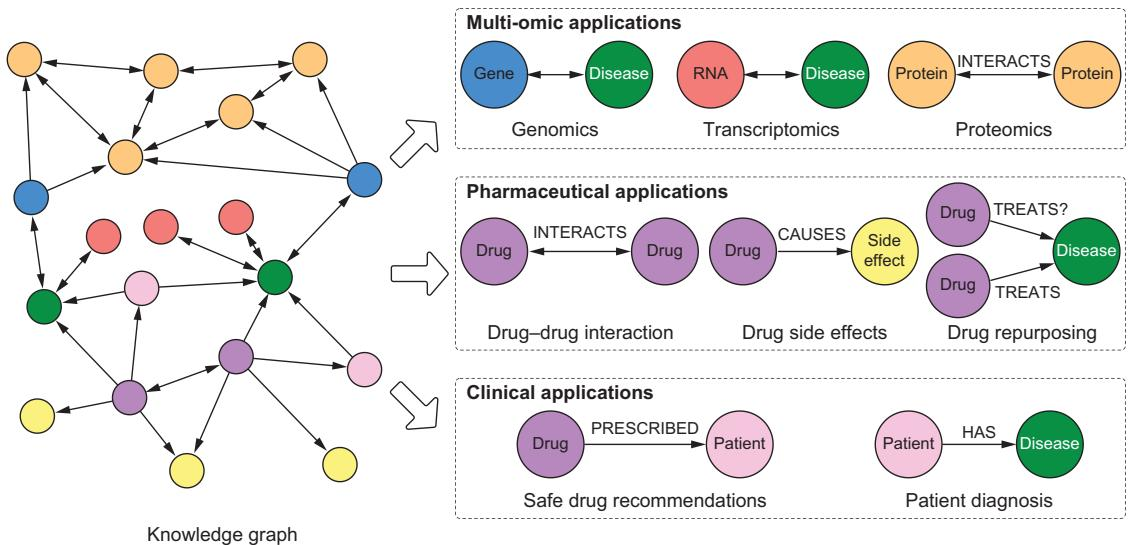

*그림 4.1 — 비즈니스 목표별로 묶은 지식 그래프의 주요 생명의학 응용 유형. 이들은 공통으로 쓰는 데이터 소스가 많다. 이 노트북의 4.2·4.3·4.4 절이 각각 다중 오믹스·제약·임상 응용에 대응한다.*

각 응용은 서로 다른 비즈니스 목표를 갖고, **CRISP-DM** 에 따라 서로 다른 소스로 구축된다. 이 장의 학습 포인트는 "지식 그래프에 넣을 데이터 소스를 어떻게 고르고, 그 정보가 원하는 작업을 해내기에 충분한지 어떻게 판단하나"다.

## 4.2 다중 오믹스 — 유전체에서 단백질까지

**다중 오믹스(multi-omic)** 는 유전체·전사체·단백질체처럼 여러 "오믹스" 데이터셋을 함께 쓰는 접근이다. 분자생물학에서 접미사 **-ome** 은 "전체 총합"을 뜻한다.

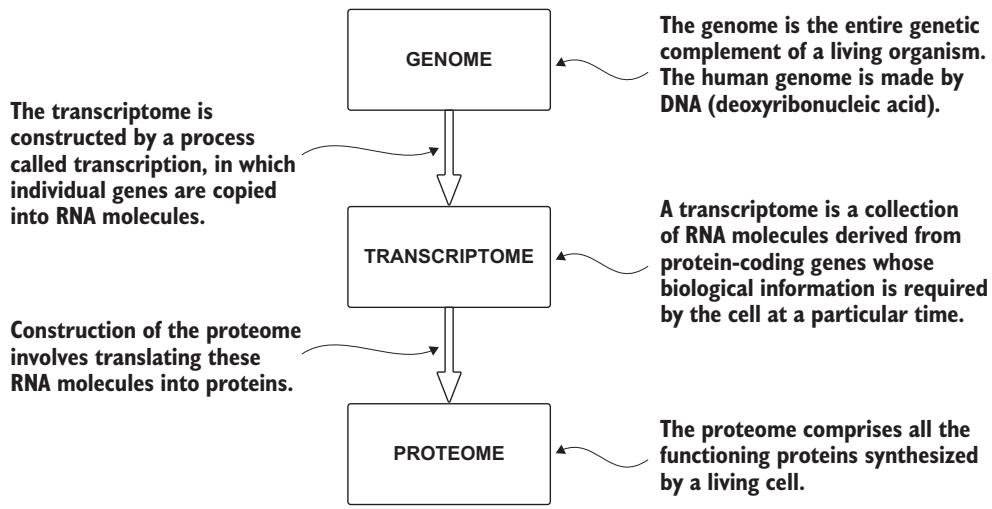

*그림 4.2 — 생명의학 KG 가 쓰는 세 가지 주요 오믹스 데이터 유형. 유전체(DNA) · 전사체(RNA) · 단백질체(단백질)는 전사(transcription)와 번역(translation)으로 생물학적으로 연결된다.*

| 용어 | 뜻 |
| --- | --- |
| **유전체 (genome)** | 생물의 유전 정보 전체. 대부분 DNA, 일부 바이러스는 RNA |
| **전사체 (transcriptome)** | 단백질체 합성을 지시하는 RNA 분자들의 집합. **전사** 로 만들어진다 |
| **단백질체 (proteome)** | 세포가 합성한 기능성 단백질 전체. 유전체 발현의 최종 산물 |

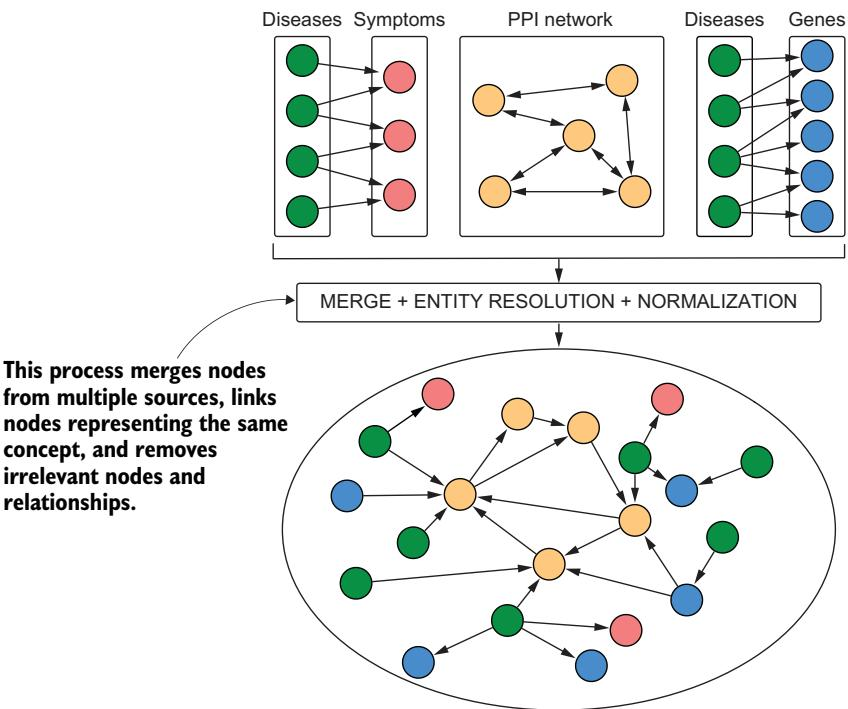

*그림 4.3 — Yang 등이 여러 이질적 소스를 병합해 하나의 통합적 KG 를 만든 방식. 서로 다른 데이터베이스의 질병 식별자를 **UMLS** 코드로 매핑해 용어를 통일했다. 3장에서 온톨로지를 기준 어휘로 쓴 것과 같은 전략이다.*

이 절에서 다룰 사례는 **단백질–단백질 상호작용(PPI)** 네트워크와 단백질–질병 연관성으로 **질병 경로** 를 계산으로 발견하는 것이다. 개별 질병 단백질을 따로 떼어 이해하려 해서는 대부분의 인간 질병을 설명할 수 없기 때문에, 지식 그래프가 핵심 역할을 하는 사례가 된다.

---
## 실행 환경 — 4장은 Neo4j Enterprise 가 필요하다

3장과 다르다. **우회가 불가능하다.** Enterprise 전용 기능이 파이프라인의 시작점에 있다.

| 리스팅 | 요구 기능 | Community |
| --- | --- | --- |
| 4.1 제약조건 | `IS NODE KEY` | ❌ Enterprise 전용 |
| 4.6 `ppi` DB | `CREATE DATABASE ... seedUri` | ❌ 멀티DB + URI 시드 |
| 4.16 `hetionet` DB | 동일 | ❌ |
| 4.20 `ckg` DB | 동일 | ❌ |

Enterprise 는 **평가(evaluation) 목적으로 무료** 다. 상용 계약이 없으면 `NEO4J_ACCEPT_LICENSE_AGREEMENT=eval` 로 평가 계약에 동의한다. 조건은 <https://neo4j.com/terms/enterprise_us/> 에 있고, 통상 비상용·비프로덕션 용도로 제한되므로 **직접 읽고 판단해 동의** 해야 한다.

```bash
docker run -d --name kglm-neo4j-ee \
  -e NEO4J_ACCEPT_LICENSE_AGREEMENT=eval \
  -e NEO4J_AUTH=neo4j/password \
  -e 'NEO4J_PLUGINS=["graph-data-science","apoc"]' \
  -e NEO4J_dbms_databases_seed__from__uri__providers=URLConnectionSeedProvider \
  -e NEO4J_dbms_security_procedures_unrestricted='gds.*,apoc.*' \
  -e NEO4J_dbms_security_procedures_allowlist='gds.*,apoc.*' \
  -e NEO4J_server_memory_heap_max__size=2G \
  -p 127.0.0.1:7474:7474 -p 127.0.0.1:7687:7687 \
  -v kglm-neo4j-ee-data:/data neo4j:5.26-enterprise
```

`seed_from_uri_providers` 는 리스팅 주석이 요구하는 `neo4j.conf` 항목을 환경변수로 준 것이다. 이게 없으면 4.6 이 실패한다.

> **⚠️ `n10s` 는 Enterprise 와 충돌한다.** 플러그인을 하나씩 시험해 확인했다. `apoc`·`gds`·둘의 조합은 정상 기동하지만 `n10s` 를 넣으면 `NoSuchMethodError: JsonProperty.isRequired()` 로 죽는다 (Jackson 버전 충돌). 그래서 위 명령에 `n10s` 가 없다.
>
> 결과적으로 **3장(n10s 필요)과 4장(Enterprise 필요)은 같은 컨테이너에서 돌릴 수 없다.** 3장 작업으로 돌아갈 때는 Community 컨테이너로 전환한다.
>
> ```bash
> docker stop kglm-neo4j-ee && docker start kglm-neo4j     # 3장용 Community 로
> docker stop kglm-neo4j && docker start kglm-neo4j-ee     # 4장용 Enterprise 로
> ```

### 데이터베이스 세 개 — `ckg` 는 선택 사항

| DB | 시드 용량 | 생성 시간 | 노드 | 관계 | 필수 |
| --- | --- | --- | --- | --- | --- |
| `ppi` | 7 MB | 5초 | 23,073 | 363,711 | ✅ 4.2 절 |
| `hetionet` | 69 MB | 8초 | 47,031 | 2,250,197 | ✅ 4.3 절 |
| `ckg` | **5.1 GB** | **약 5분** | 18,606,441 | 205,971,182 | ⬜ 4.4 절만 |

`ckg` 를 쓰는 리스팅은 4.20(생성)·4.21(질의) **둘뿐** 이다. 5.1GB 가 부담이면 건너뛰어도 장의 흐름에 지장이 없다. 이 노트북은 아래 `RUN_CKG` 플래그로 제어하고, 건너뛸 경우 실측 결과를 마크다운으로 보존해 무엇이 나오는지 알 수 있게 했다.

In [1]:
"""환경 점검 — 이 셀이 통과하면 4.2·4.3 절을 모두 돌릴 수 있다."""
from pathlib import Path

from studykit import config, cypher

STUDY = config.load()      # 위로 올라가며 study.toml 을 찾는다
HERE = Path.cwd()          # 주피터는 노트북 폴더를 cwd 로 둔다

RUN_CKG = False            # True 로 바꾸면 4.4 절의 5.1GB ckg 도 만든다

assert (HERE / "listings").is_dir(), f"리스팅 폴더가 없다. cwd 확인: {HERE}"

print("교재        :", STUDY.title)
print("리스팅 오프셋:", STUDY.listing_offsets.get("ch04"), "(0 = 책 번호와 파일 번호가 같다)")

with cypher.driver() as drv, drv.session(database="system") as s:
    info = s.run("CALL dbms.components() YIELD versions, edition "
                 "RETURN versions[0] AS version, edition").single()
    print(f"Neo4j       : {info['version']} ({info['edition']} edition)")
    if info["edition"] != "enterprise":
        raise RuntimeError(
            "4장은 Enterprise 가 필요하다. CREATE DATABASE ... seedUri 와 IS NODE KEY 가\n"
            "  Community 에 없다. 위 docker run 명령으로 Enterprise 컨테이너를 띄워라."
        )
    existing = {r["name"] for r in s.run("SHOW DATABASES YIELD name RETURN DISTINCT name")}
    print("데이터베이스 :", sorted(existing))

with cypher.driver() as drv, drv.session(database="neo4j") as s:
    plugins = s.run("SHOW PROCEDURES YIELD name "
                    "WHERE name STARTS WITH 'gds' OR name STARTS WITH 'apoc' "
                    "RETURN split(name,'.')[0] AS ns, count(*) AS n ORDER BY ns").data()
    print("플러그인     :", {p["ns"]: p["n"] for p in plugins})
    if not any(p["ns"] == "gds" for p in plugins):
        raise RuntimeError("GDS 가 없다. 4.8~4.10 의 WCC·Louvain 을 돌릴 수 없다.")

print("\n준비 완료.")

교재        : Knowledge Graphs and LLMs in Action
리스팅 오프셋: 0 (0 = 책 번호와 파일 번호가 같다)
Neo4j       : 5.26.28 (enterprise edition)
데이터베이스 : ['ckg', 'hetionet', 'neo4j', 'ppi', 'system']
플러그인     : {'apoc': 190, 'gds': 423}

준비 완료.


In [2]:
"""리스팅 접근 헬퍼.

3장과 달리 오프셋이 0 이라 책 번호와 파일 번호가 같다. 대신 리스팅마다 실행할
데이터베이스가 다르므로(ppi / hetionet / ckg) db 를 명시한다.
"""
import time

LISTING_OFFSET = STUDY.listing_offsets["ch04"]   # study.toml 이 정본


def source_of(book_no: str) -> str:
    major, minor = book_no.split(".")
    return cypher.read(f"{major}.{int(minor) + LISTING_OFFSET}", HERE / "listings").strip()


def show(book_no: str) -> None:
    print(f"── 책 Listing {book_no} ──")
    print(source_of(book_no))


def statements(book_no: str) -> list:
    """주석만으로 된 조각은 버린다. 4.6·4.16·4.20 은 앞부분이 neo4j.conf 안내 주석이다."""
    out = []
    for chunk in source_of(book_no).split(";"):
        lines = [l for l in chunk.strip().splitlines() if l.strip()]
        if lines and not all(l.strip().startswith("#") for l in lines):
            out.append("\n".join(l for l in lines if not l.strip().startswith("#")).strip())
    return out


def run(book_no: str, db: str, limit: int = 5, **params):
    """책 리스팅을 지정한 데이터베이스에서 실행한다."""
    started = time.time()
    rows = []
    with cypher.driver() as drv, drv.session(database=db) as s:
        for statement in statements(book_no):
            rows = [r.data() for r in s.run(statement, **params)]
    print(f"책 {book_no} [{db}]: {time.time() - started:.1f}초, {len(rows)}행")
    for r in rows[:limit]:
        print("   ", {k: str(v)[:58] for k, v in r.items()})
    return rows


def db_stats(db: str) -> dict:
    with cypher.driver() as drv, drv.session(database=db) as s:
        return {
            "nodes": s.run("MATCH (n) RETURN count(n) AS n").single()["n"],
            "rels": s.run("MATCH ()-[r]->() RETURN count(r) AS n").single()["n"],
        }


# 4장 리스팅 전체 대조표 (오프셋 0 이라 그대로 대응한다)
print(f"{'책':<7}저장소 파일")
for path in cypher.listings(HERE / "listings"):
    print(f"{path.name.split(' ')[0]:<7}{path.name}")

책      저장소 파일
4.1    4.1 Create the constraints
4.2    4.2 Import PPI Network
4.3    4.3 Import pathways
4.4    4.4 Import disease classes
4.5    4.5 Import gene info
4.6    4.6 Create the PPI database from a neo4j backup
4.7    4.7 Creating a temporal label to mark the proteins in the PPI Network
4.8    4.8 Create the graph projection in memory
4.9    4.9 Run WCC on the PPI Network
4.10   4.10 Run Louvain on the PPI Network
4.11   4.11 Inspect the top 10 communities’ content
4.12   4.12 Extracting disease pathway from the knowledge graph
4.16   4.16 Create the Het.io database
4.17   4.17 GO Process enrichment for celiac disease
4.18   4.18 Tissue-specific interactomics. GO Process enrichment for celiac disease
4.19   4.19 Paths behind the DWPC for positive regulation of glycoprotein biosynthetic process relationship
4.20   4.20 Importing CKG database
4.21   4.21 Known protein to disease association


---
### 4.2.1 PPI 와 단백질–질병 네트워크로 KG 만들기

목표는 **이미 알려진 경로에서 출발해 새로운 질병 경로를 발견** 하는 것이다.

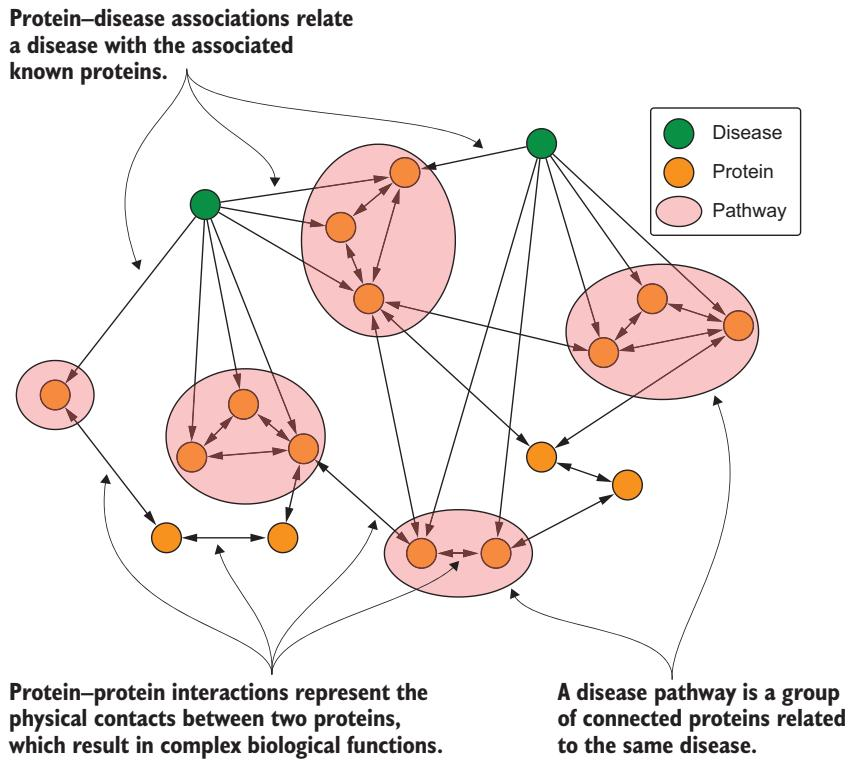

*그림 4.4 — 질병 경로(disease pathway)는 그 질병과 연관된 단백질 집합으로 정의되는 PPI 네트워크의 **부분 그래프** 다. 이 정의가 4.2.3 절 지표 세 개의 출발점이 된다.*

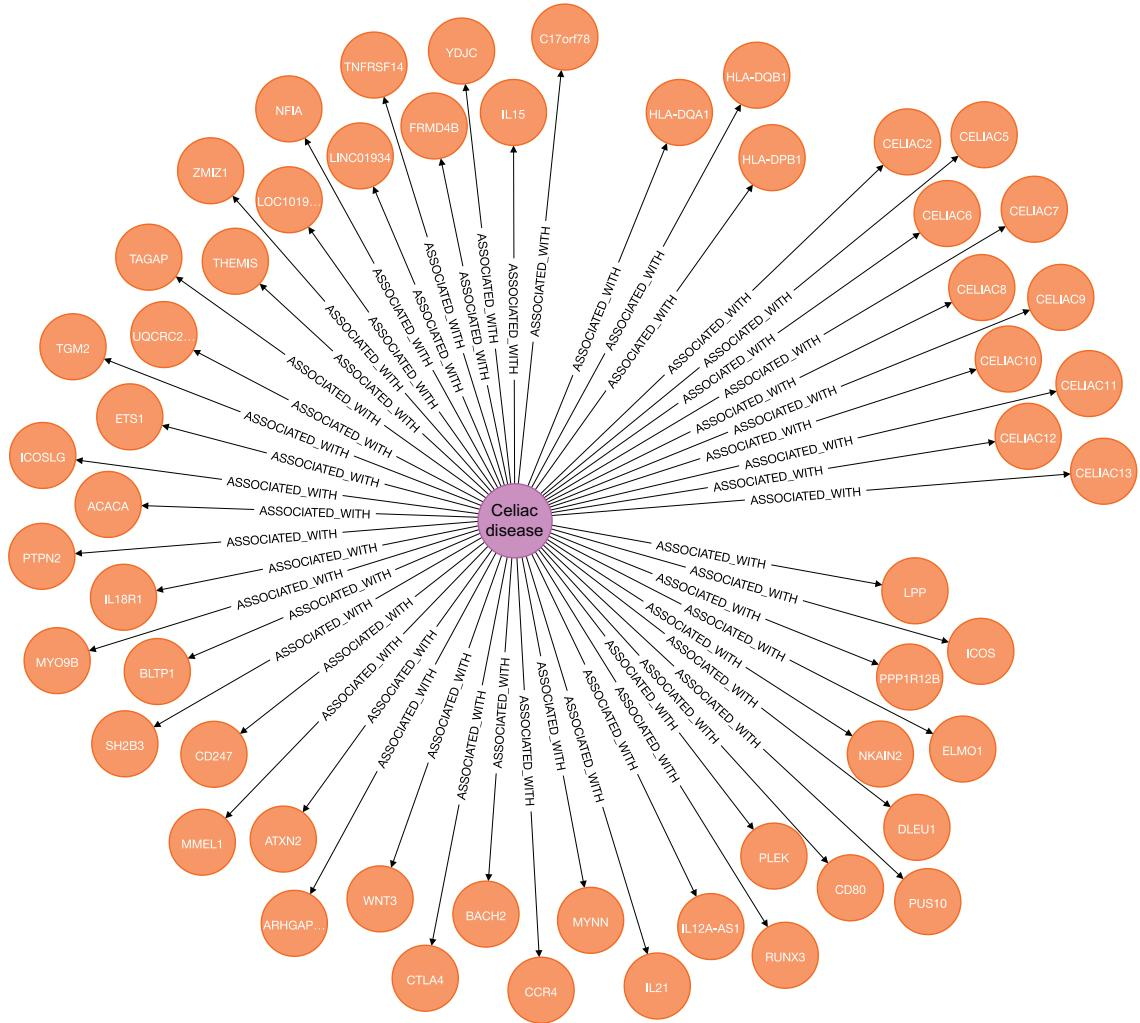

*그림 4.5 — Agrawal 이 구축한 KG 의 작은 일부. 셀리악병에서 출발해 연관 유전자들을 찾은 모습. 셀리악병은 4.3 절에서도 계속 등장한다.*

만들어지는 그래프는 두 부분으로 이루어진다.

- **단일 분할 그래프(monopartite)** — 한 종류의 노드끼리 연결된 PPI 네트워크 (`Protein`—`INTERACTS_WITH`—`Protein`)

- **이분 그래프(bipartite)** — 두 종류의 노드가 연결된 질병–단백질 연관 네트워크 (`Disease`—`ASSOCIATED_WITH`—`Protein`)

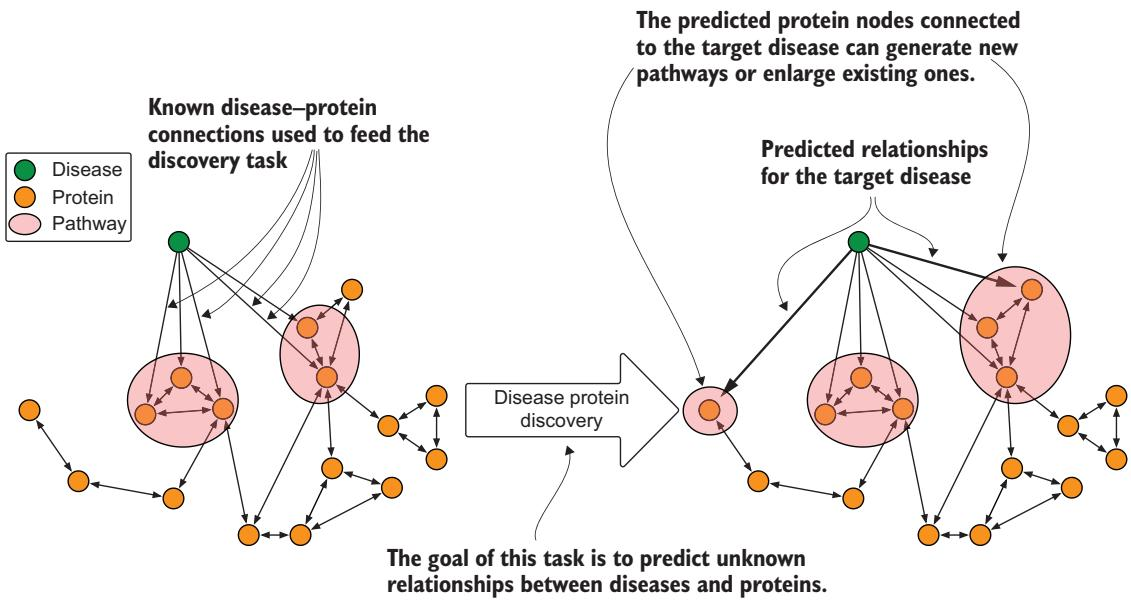

*그림 4.6 — 질병과 관련된 단백질을 찾아내는 발견 과정. 이미 알려진 경로 집합이 입력이고, 지능형 자문 시스템이 연관 가능성 있는 단백질과 경로를 예측해 보고한다.*

### 소스 데이터와 리스팅 4.1\~4.5

| 리스팅 | 소스 | 담는 것 |
| --- | --- | --- |
| 4.1 | — | `Protein`·`Disease` 노드 키 제약 |
| 4.2 | SNAP `bio-pathways-network.csv` | 인간 단백질 21,559개 사이 상호작용 342,354건 |
| 4.3 | SNAP `bio-pathways-associations.csv` | DisGeNET 유래 단백질–질병 연관 21,000+건, 519개 질병 |
| 4.4 | SNAP `bio-pathways-diseaseclasses.csv` | Disease Ontology 2계층 10개 범주 (암 68, 신경계 44, 심혈관 33, 면역 21) |
| 4.5 | NIH `gene_info` | 코드뿐인 단백질에 사람이 읽을 심볼·설명 부여 |

> **4.1\~4.5 는 이 노트북에서 실행하지 않는다.** 세 가지 이유다. 첫째 `LOAD CSV FROM 'file:///PPI/...'` 는 CSV 를 Neo4j 컨테이너의 import 디렉터리에 미리 넣어야 한다. 둘째 그 CSV 원본이 교재 저장소에 없고 Readme 도 출처를 밝히지 않는다. 셋째 `IS NODE KEY` 는 Enterprise 전용이다.
>
> 해설판이 바로 이 상황을 위해 **4.6 의 백업 시드 경로** 를 제공한다. "만약 여기까지 직접 따라 하지 않았더라도 걱정 없습니다." 아래 셀이 그 경로를 쓴다.

In [3]:
"""책 4.1~4.5 원문 확인 — 실행하지 않고 무엇을 하는 코드인지만 본다.

4.2 는 CSV 각 줄에서 두 단백질을 MERGE 하고 INTERACTS_WITH 로 잇는다.
IN TRANSACTIONS OF 100 ROWS 는 100줄씩 끊어 커밋해 메모리 부담을 줄이는 관용구다.
4.3 은 쉼표로 이어진 유전자 ID 목록을 split + UNWIND 로 펼쳐 관계를 만든다.
4.5 는 MATCH 로 기존 노드를 찾아 name·description 만 덧붙인다 (새 노드를 만들지 않는다).
"""
for book_no in ("4.1", "4.2", "4.5"):
    show(book_no)
    print()

── 책 Listing 4.1 ──
CREATE CONSTRAINT protein_key IF NOT EXISTS FOR (n:Protein) REQUIRE (n.id) IS NODE KEY;
CREATE CONSTRAINT disease_key IF NOT EXISTS FOR (n:Disease) REQUIRE (n.id) IS NODE KEY;

── 책 Listing 4.2 ──
:auto LOAD CSV FROM 'file:///PPI/bio-pathways-network.csv' AS line
CALL {
    WITH line
    MERGE (f:Protein {id: trim(line[0])})
    MERGE (s:Protein {id: trim(line[1])})
    MERGE (f)-[:INTERACTS_WITH]->(s)
} IN TRANSACTIONS OF 100 ROWS

── 책 Listing 4.5 ──
:auto LOAD CSV WITH HEADERS FROM 'file:///PPI/gene_info' AS line FIELDTERMINATOR '\t'
CALL {
    WITH line
    WITH trim(line["GeneID"]) AS proteinId, trim(line["Symbol"]) AS symbol,
    trim(line["description"]) AS description
    WITH proteinId, symbol, description
    MATCH (p:Protein {id:proteinId})
    SET p.name = symbol, p.description = description
} IN TRANSACTIONS OF 100 ROWS



### 리스팅 4.6 — 백업 시드로 `ppi` 데이터베이스 만들기

`CREATE DATABASE ... OPTIONS { existingData: "use", seedUri: ... }` 는 원격 백업 파일을 끌어와 데이터베이스를 만든다. Enterprise 전용이고, 컨테이너에 `dbms.databases.seed_from_uri_providers=URLConnectionSeedProvider` 설정이 있어야 한다.

시드 파일은 7MB 이고 실측 **5초** 에 온라인이 된다. 4.1\~4.5 를 직접 돌려 만든 것과 같은 그래프다.

In [4]:
"""책 4.6 — 백업 시드로 ppi 데이터베이스 생성.

CREATE DATABASE 는 비동기다. 명령이 돌아와도 아직 starting 상태일 수 있으므로
online 이 될 때까지 기다려야 한다. 5.4.0 처럼 오래된 백업은 현재 버전으로
마이그레이션하느라 더 오래 걸린다 (4.20 의 ckg 가 그렇다).
"""
def wait_online(db: str, timeout: int = 600) -> float | None:
    started = time.time()
    while time.time() - started < timeout:
        with cypher.driver() as drv, drv.session(database="system") as s:
            rows = s.run(f"SHOW DATABASE {db} YIELD currentStatus "
                         f"RETURN currentStatus AS st").data()
        if rows and rows[0]["st"] == "online":
            return time.time() - started
        time.sleep(2)
    return None


show("4.6")

with cypher.driver() as drv, drv.session(database="system") as s:
    already = s.run("SHOW DATABASES YIELD name RETURN collect(DISTINCT name) AS n").single()["n"]

if "ppi" in already:
    print("\n이미 존재 — 건너뜀")
else:
    print("\n생성 중...")
    for statement in statements("4.6"):
        with cypher.driver() as drv, drv.session(database="system") as s:
            s.run(statement).consume()
    elapsed = wait_online("ppi")
    print(f"online ({elapsed:.1f}초)" if elapsed else "타임아웃")

print("ppi 규모:", {k: f"{v:,}" for k, v in db_stats("ppi").items()})

── 책 Listing 4.6 ──
# Add the following line to the neo4j.conf file
# dbms.databases.seed_from_uri_providers=URLConnectionSeedProvider
# then run the following command

CREATE DATABASE ppi OPTIONS { existingData: "use", seedUri: "https://downloads.graphaware.com/neo4j-db-seeds/ppi-5.26.4-2025-03-22T08-30-33.backup"}

이미 존재 — 건너뜀
ppi 규모: {'nodes': '23,073', 'rels': '363,711'}


In [5]:
"""실습 4-A — 해설판 4.2.1 의 연습문제 세 개.

(1) 4.2 직후의 단백질 수와 연결 수를 확인하라. 다음 단계가 새 단백질을 추가하므로
    반드시 그 전에 봐야 한다.
(2) 4.3 이후 단백질 수가 달라진다. 새로 생긴 단백질을 찾아라. 힌트: NOT EXISTS
(3) 질병의 범주별 수치와, 범주가 없는 질병 목록을 확인하라.

백업 시드로 만든 그래프는 4.2~4.5 가 모두 끝난 상태다. 그래서 (1)(2)를 시간 순서로
재현할 수는 없다. 대신 "그 차이가 그래프에 남긴 흔적"을 찾는 방식으로 푼다.
"""
QUERIES = {
    "(1) 전체 단백질·상호작용 수": """
        MATCH (p:Protein) WITH count(p) AS proteins
        MATCH ()-[r:INTERACTS_WITH]->() RETURN proteins, count(r) AS interactions""",
    "(2) PPI 상호작용이 없는 단백질 = 4.3 이 새로 만든 것": """
        MATCH (p:Protein)
        WHERE NOT EXISTS { (p)-[:INTERACTS_WITH]-() }
        RETURN count(p) AS only_from_associations""",
    "(2b) 그중 표본": """
        MATCH (p:Protein)
        WHERE NOT EXISTS { (p)-[:INTERACTS_WITH]-() }
        MATCH (d:Disease)-[:ASSOCIATED_WITH]->(p)
        RETURN p.id AS protein_id, p.name AS name, collect(d.name)[..2] AS diseases
        LIMIT 5""",
    "(3) 질병 범주별 수": """
        MATCH (d:Disease)
        RETURN coalesce(d.class, '(범주 없음)') AS class, count(*) AS diseases
        ORDER BY diseases DESC""",
}

with cypher.driver() as drv, drv.session(database="ppi") as s:
    for label, query in QUERIES.items():
        print(f"\n── {label}")
        for row in s.run(query).data():
            print("   ", {k: str(v)[:56] for k, v in row.items()})


── (1) 전체 단백질·상호작용 수


    {'proteins': '22554', 'interactions': '342354'}

── (2) PPI 상호작용이 없는 단백질 = 4.3 이 새로 만든 것
    {'only_from_associations': '995'}

── (2b) 그중 표본


    {'protein_id': '57419', 'name': 'SLC24A3', 'diseases': "['Salivary Gland Neoplasms', 'Adenoid Cystic Carcinoma']"}
    {'protein_id': '65245', 'name': 'PSORS7', 'diseases': "['Psoriasis']"}
    {'protein_id': '140454', 'name': 'PSORS8', 'diseases': "['Psoriasis']"}
    {'protein_id': '503613', 'name': 'PSORS10', 'diseases': "['Psoriasis']"}
    {'protein_id': '10547', 'name': 'PSORS4', 'diseases': "['Psoriasis']"}

── (3) 질병 범주별 수


    {'class': '(범주 없음)', 'diseases': '219'}
    {'class': 'cancer', 'diseases': '68'}
    {'class': 'nervous system disease', 'diseases': '44'}
    {'class': 'cardiovascular system disease', 'diseases': '33'}
    {'class': 'immune system disease', 'diseases': '21'}
    {'class': 'gastrointestinal system disease', 'diseases': '16'}
    {'class': 'musculoskeletal system disease', 'diseases': '16'}
    {'class': 'inherited metabolic disorder', 'diseases': '12'}
    {'class': 'urinary system disease', 'diseases': '11'}
    {'class': 'acquired metabolic disease', 'diseases': '10'}
    {'class': 'monogenic disease', 'diseases': '10'}
    {'class': 'respiratory system disease', 'diseases': '9'}
    {'class': 'integumentary system disease', 'diseases': '8'}
    {'class': 'benign neoplasm', 'diseases': '7'}
    {'class': 'endocrine system disease', 'diseases': '6'}
    {'class': 'viral infectious disease', 'diseases': '4'}
    {'class': 'cognitive disorder', 'diseases': '4'}
    {'class': 'subs

---
### 4.2.2 고수준 분석 — 전체 구조 살펴보기

먼저 PPI 네트워크 **전체** 가 어떻게 구성돼 있는지 본다. 쓰는 알고리즘은 **약하게 연결된 컴포넌트(WCC)** — 그래프 안에서 서로 끊긴 부분 그래프를 찾는다 — 와 **Louvain** — 모듈성을 최대화하는 커뮤니티를 찾는다 — 이고, Neo4j **GDS** 라이브러리로 실행한다.

순서에 이유가 있다.

1. **4.7** `INTERACTS_WITH` 로 연결된 단백질에만 `PPIProtein` 레이블을 붙인다. 4.3 이 만든 "연관만 있고 상호작용은 없는" 단백질을 분석에서 빼기 위한 임시 표시다
2. **4.8** 그 레이블로 인메모리 그래프를 투영한다. GDS 는 디스크 그래프를 직접 읽지 않고 투영본에서 계산한다. `orientation: 'UNDIRECTED'` 는 상호작용이 방향 없는 관계임을 반영한다
3. **4.9** WCC 로 끊긴 덩어리를 센다
4. **4.10** Louvain 으로 커뮤니티를 나눈다
5. **4.11** 큰 커뮤니티의 내용을 들여다본다

In [6]:
"""책 4.7~4.11 — GDS 커뮤니티 탐지 파이프라인.

투영본(ppi-graph)이 이미 있으면 4.8 이 실패하므로 먼저 지운다. GDS 투영은
데이터베이스가 아니라 세션 메모리에 살아 있어 재실행 시 충돌한다.
"""
for book_no in ("4.7", "4.8", "4.9", "4.10", "4.11"):
    show(book_no)
    print()

with cypher.driver() as drv, drv.session(database="ppi") as s:
    s.run("CALL gds.graph.drop('ppi-graph', false)").consume()   # 없어도 에러 안 남

run("4.7", "ppi", limit=0)
run("4.8", "ppi", limit=1)

wcc = run("4.9", "ppi", limit=1)
print(f"   -> 연결 컴포넌트 {wcc[0]['componentCount']}개")

louvain = run("4.10", "ppi", limit=1)
print(f"   -> 커뮤니티 {louvain[0]['communityCount']}개, "
      f"모듈성 {louvain[0]['modularity']:.4f}")

top = run("4.11", "ppi", limit=0)
print("\n상위 커뮤니티 (멤버 수 · 대표 유전자):")
for row in top[:5]:
    members = row["keyMembers"][:6]
    print(f"   {row['members']:>5}명  {', '.join(m for m in members if m)}")

── 책 Listing 4.7 ──
MATCH (p:Protein)-[:INTERACTS_WITH]-()
SET p:PPIProtein

── 책 Listing 4.8 ──
call gds.graph.project(
    'ppi-graph',
    'PPIProtein',
    {
        INTERACTS_WITH: {
            orientation: 'UNDIRECTED'
        }
    }
)

── 책 Listing 4.9 ──
CALL gds.wcc.write('ppi-graph', { writeProperty: 'componentId' })
YIELD nodePropertiesWritten, componentCount, componentDistribution;

── 책 Listing 4.10 ──
CALL gds.louvain.write('ppi-graph',
{ writeProperty: 'componentLouvainId' })
YIELD communityCount, modularity, modularities, communityDistribution

── 책 Listing 4.11 ──
MATCH (p:PPIProtein)
WITH p.componentLouvainId as communityId, count(p) as members
ORDER BY members desc
LIMIT 10
MATCH (p:PPIProtein)-[:INTERACTS_WITH]-(o)
WHERE p.componentLouvainId = communityId
WITH communityId, members, p.name as name, count(o) as connections
ORDER BY connections DESC
RETURN communityId, members, collect(name)[..20] as keyMembers



Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated field from a procedure. ('schema' returned by 'gds.graph.drop' is deprecated.)} {position: line: 1, column: 1, offset: 0} for query: "CALL gds.graph.drop('ppi-graph', false)"


책 4.7 [ppi]: 0.1초, 0행


책 4.8 [ppi]: 0.0초, 1행
    {'nodeProjection': "{'PPIProtein': {'properties': {}, 'label': 'PPIProtein'}}", 'relationshipProjection': "{'INTERACTS_WITH': {'orientation': 'UNDIRECTED', 'aggregat", 'graphName': 'ppi-graph', 'nodeCount': '21559', 'relationshipCount': '684708', 'projectMillis': '20'}
책 4.9 [ppi]: 0.0초, 1행
    {'nodePropertiesWritten': '21559', 'componentCount': '27', 'componentDistribution': "{'p1': 1, 'max': 21521, 'p5': 1, 'p90': 3, 'p50': 1, 'p95'"}
   -> 연결 컴포넌트 27개


책 4.10 [ppi]: 13.8초, 1행
    {'communityCount': '42', 'modularity': '0.39511439336115206', 'modularities': '[0.37169140463021433, 0.3948335206788366, 0.39511439336115', 'communityDistribution': "{'p1': 1, 'max': 3493, 'p5': 1, 'p90': 2820, 'p50': 2, 'p9"}
   -> 커뮤니티 42개, 모듈성 0.3951


책 4.11 [ppi]: 0.3초, 10행

상위 커뮤니티 (멤버 수 · 대표 유전자):
    3493명  APP, GRB2, EGFR, HSP90AA1, SRC, CALM1
    2820명  NTRK1, XPO1, YWHAZ, VCP, YWHAG, BAG3
    3217명  ELAVL1, MOV10, NXF1, FBXO6, SHMT2, TMEM17
    1584명  UBC, TRAF6, HSPA5, PRKN, HSPA1A, BAG6
    1444명  CUL3, MCM2, COPS5, FN1, CUL1, RNF2


---
### 4.2.3 도메인 특화 분석 — 질병 경로를 자로 재다

앞은 네트워크 **전체** 를 봤다. 이제 **부분 그래프**, 즉 질병 경로를 잰다.

PPI 네트워크를 $G = (V, E)$ 라 하면 (노드 $V$ = 단백질, 엣지 $E$ = 상호작용), 질병 $d$ 의 질병 경로는 무방향 부분 그래프 $H_d = (V_d, E_d)$ 다.

$$E_{d} = \{ (u, v) \mid (u, v) \in E \text{ and } u, v \in V_{d} \}$$

즉 **양쪽 끝이 모두 질병 단백질인 상호작용만** 골라낸 것이다. 지표를 계산할 때는 이 부분 그래프가 나머지와 어떻게 이어져 있는지도 봐야 하므로 **경로 경계** $B_d$ 를 함께 정의한다.

$$B_{d} = \{ (u, v) \mid (u, v) \in E \text{ and } u \in V_{d} \text{ and } v \in V \setminus V_{d} \}$$

한쪽 끝은 질병 단백질, 다른 쪽은 아닌 **안과 밖을 잇는 엣지** 집합이다. 이 둘로 지표 세 개를 만든다.

| 지표 | 수식 | 읽는 법 |
| --- | --- | --- |
| **가장 큰 경로 컴포넌트** | $\dfrac{\lvert \text{nodes}(\text{largestCC}(H_d)) \rvert}{\lvert V_d \rvert}$ | 질병 단백질이 한 덩어리로 뭉쳤나. 1 에 가까우면 하나로 뭉침 |
| **밀도** | $\dfrac{2\lvert E_d \rvert}{\lvert V_d \rvert (\lvert V_d \rvert - 1)}$ | 경로 **안** 이 얼마나 촘촘한가. [0,1] |
| **전도도** | $\dfrac{\lvert B_d \rvert}{\lvert B_d \rvert + 2\lvert E_d \rvert}$ | 경로가 나머지와 얼마나 **분리** 됐나. 낮을수록 독립적 커뮤니티 |

구현은 `analysis/multiomic_analysis.py` 에 있고 `networkx` 를 쓴다. 아래 셀이 셀리악병에 대해 세 지표를 직접 계산한다.

In [7]:
"""책 4.12~4.15 — 질병 경로 지표 세 개를 셀리악병에 대해 계산한다.

4.12 로 질병 경로 부분 그래프를 뽑고, 4.13~4.15 의 수식을 그대로 옮겼다.
업스트림 analysis/multiomic_analysis.py 는 networkx 로 같은 일을 한다. 여기서는
질병 경로가 작으므로(단백질 수십~수백 개) 파이썬 BFS 로 직접 센다. 의존성이 줄고
"연결 컴포넌트를 센다"는 것이 무슨 뜻인지도 눈에 보인다.

★ 이름 표기가 소스마다 다르다. ppi 는 'Celiac Disease'(Title Case), hetionet 은
  'celiac disease'(lower case) 다. 같은 질병인데 표기가 갈린다. 바로 이것이 4장이
  말하는 "이름과 식별자를 서로 맞춰(reconcile) 짝짓기" 문제의 실물이다.
"""
from collections import deque

show("4.12")

DISEASE = "celiac disease"      # 비교는 toLower() 로 한다

PATHWAY = """
MATCH (d:Disease)-[:ASSOCIATED_WITH]->(p:Protein)
WHERE toLower(d.name) = toLower($name)
WITH d, collect(DISTINCT p) AS proteins
CALL (proteins) {
    // Ed: 양쪽 끝이 모두 질병 단백질인 상호작용
    MATCH (m0)-[:INTERACTS_WITH]-(m1)
    WHERE m0 IN proteins AND m1 IN proteins
    RETURN collect(DISTINCT [elementId(m0), elementId(m1)]) AS inside
}
CALL (proteins) {
    // Bd: 한쪽만 질병 단백질인 상호작용 (경로 경계)
    MATCH (m0)-[r:INTERACTS_WITH]-(m1)
    WHERE m0 IN proteins AND NOT m1 IN proteins
    RETURN count(DISTINCT r) AS bd
}
RETURN d.id AS disease_id, d.name AS disease_name,
       [p IN proteins | elementId(p)] AS node_ids, inside, bd
"""

with cypher.driver() as drv, drv.session(database="ppi") as s:
    row = s.run(PATHWAY, name=DISEASE).single()
if row is None:
    raise RuntimeError(f"ppi 에서 '{DISEASE}' 를 찾지 못했다. 표기를 확인하라.")

print(f"\nppi 의 실제 표기: {row['disease_name']} ({row['disease_id']})")

nodes = set(row["node_ids"])
# 무방향으로 다루므로 양쪽 방향을 모두 넣는다
adjacency = {n: set() for n in nodes}
edges = set()
for a, b in row["inside"]:
    if a in adjacency and b in adjacency:
        adjacency[a].add(b)
        adjacency[b].add(a)
        edges.add(frozenset((a, b)))

vd, ed, bd = len(nodes), len(edges), row["bd"]


def connected_components(adj: dict) -> list[int]:
    """BFS 로 연결 컴포넌트 크기 목록을 구한다 (큰 것부터)."""
    seen, sizes = set(), []
    for start in adj:
        if start in seen:
            continue
        queue, size = deque([start]), 0
        seen.add(start)
        while queue:
            current = queue.popleft()
            size += 1
            for neighbour in adj[current] - seen:
                seen.add(neighbour)
                queue.append(neighbour)
        sizes.append(size)
    return sorted(sizes, reverse=True)


sizes = connected_components(adjacency)
relative_largest = sizes[0] / vd
density = 2.0 * ed / (vd * (vd - 1))
conductance = bd / (bd + 2 * ed)

print(f"\n=== {DISEASE} 질병 경로 지표 ===")
print(f"  |Vd| 질병 단백질          : {vd}")
print(f"  |Ed| 내부 상호작용        : {ed}")
print(f"  |Bd| 경계 상호작용        : {bd:,}")
print(f"  연결 컴포넌트 수          : {len(sizes)}      (책 전체 중앙값 16)")
print(f"  가장 큰 컴포넌트 크기     : {sizes[0]}")
print(f"  가장 큰 컴포넌트 상대크기 : {relative_largest:.3f}   (책 중앙값 0.21)")
print(f"  밀도                      : {density:.4f}  (책 중앙값 0.07 · PPI 전체 0.0015)")
print(f"  전도도                    : {conductance:.4f}  (책 중앙값 0.96)")
print(f"  컴포넌트 크기 분포        : {sizes[:12]}{' ...' if len(sizes) > 12 else ''}")
print("\n해석: 밀도가 낮고 전도도가 높으면 그 질병의 단백질들은 서로 뭉쳐 있기보다")
print("      네트워크 곳곳에 흩어져 다른 단백질들과 뒤섞여 있다는 뜻이다.")


── 책 Listing 4.12 ──
MATCH (d:Disease {id:$id})-[:ASSOCIATED_WITH]->(p)
WITH collect(p) as proteins
UNWIND proteins as m0
UNWIND proteins as m1
OPTIONAL MATCH (m0)-[r:INTERACTS_WITH]->(m1)
RETURN DISTINCT m0, r, m1



ppi 의 실제 표기: Celiac Disease (C0007570)

=== celiac disease 질병 경로 지표 ===
  |Vd| 질병 단백질          : 55
  |Ed| 내부 상호작용        : 15
  |Bd| 경계 상호작용        : 1,003
  연결 컴포넌트 수          : 50      (책 전체 중앙값 16)
  가장 큰 컴포넌트 크기     : 3
  가장 큰 컴포넌트 상대크기 : 0.055   (책 중앙값 0.21)
  밀도                      : 0.0101  (책 중앙값 0.07 · PPI 전체 0.0015)
  전도도                    : 0.9710  (책 중앙값 0.96)
  컴포넌트 크기 분포        : [3, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1] ...

해석: 밀도가 낮고 전도도가 높으면 그 질병의 단백질들은 서로 뭉쳐 있기보다
      네트워크 곳곳에 흩어져 다른 단백질들과 뒤섞여 있다는 뜻이다.
